# video3 notebook - Ravelling Detection
Notebook for detecting road surface deterioration (ravelling, potholes, aggregate loss).

In [1]:
import cv2
video_path = 'videos/ravelling.mp4'

In [2]:
import os
output_folder = "extracted_All_framesVideo3"
os.makedirs(output_folder, exist_ok=True)

In [3]:
cap = cv2.VideoCapture(video_path)

In [4]:
cap.isOpened()

True

In [5]:
cap = cv2.VideoCapture(video_path)
fps=cap.get(cv2.CAP_PROP_FPS)
total_frames= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec=total_frames/fps

print('FPS:',fps)
print('Total Frames:',total_frames)
print('Video Duration(sec:)',duration_sec)
if not cap.isOpened():
    print("Error: Cannot open video")
    exit()

FPS: 30.0
Total Frames: 873
Video Duration(sec:) 29.1


In [6]:
frame_count = 0
saved_count = 0


while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % 5 == 0:
        resized = cv2.resize(frame, (640, 480))  
        filename = os.path.join(output_folder, f"frame_{saved_count}.jpg")
        cv2.imwrite(filename, resized)
        saved_count += 1

    frame_count += 1

cap.release()
print("Frame extraction completed!")
print("Total frames saved:", saved_count)

Frame extraction completed!
Total frames saved: 175


## Random 30-frame degradation analysis
This section:
- randomly selects 30 extracted frames,
- plots grayscale histograms,
- estimates noise, illumination issues, and blur,
- marks likely degradations per frame.

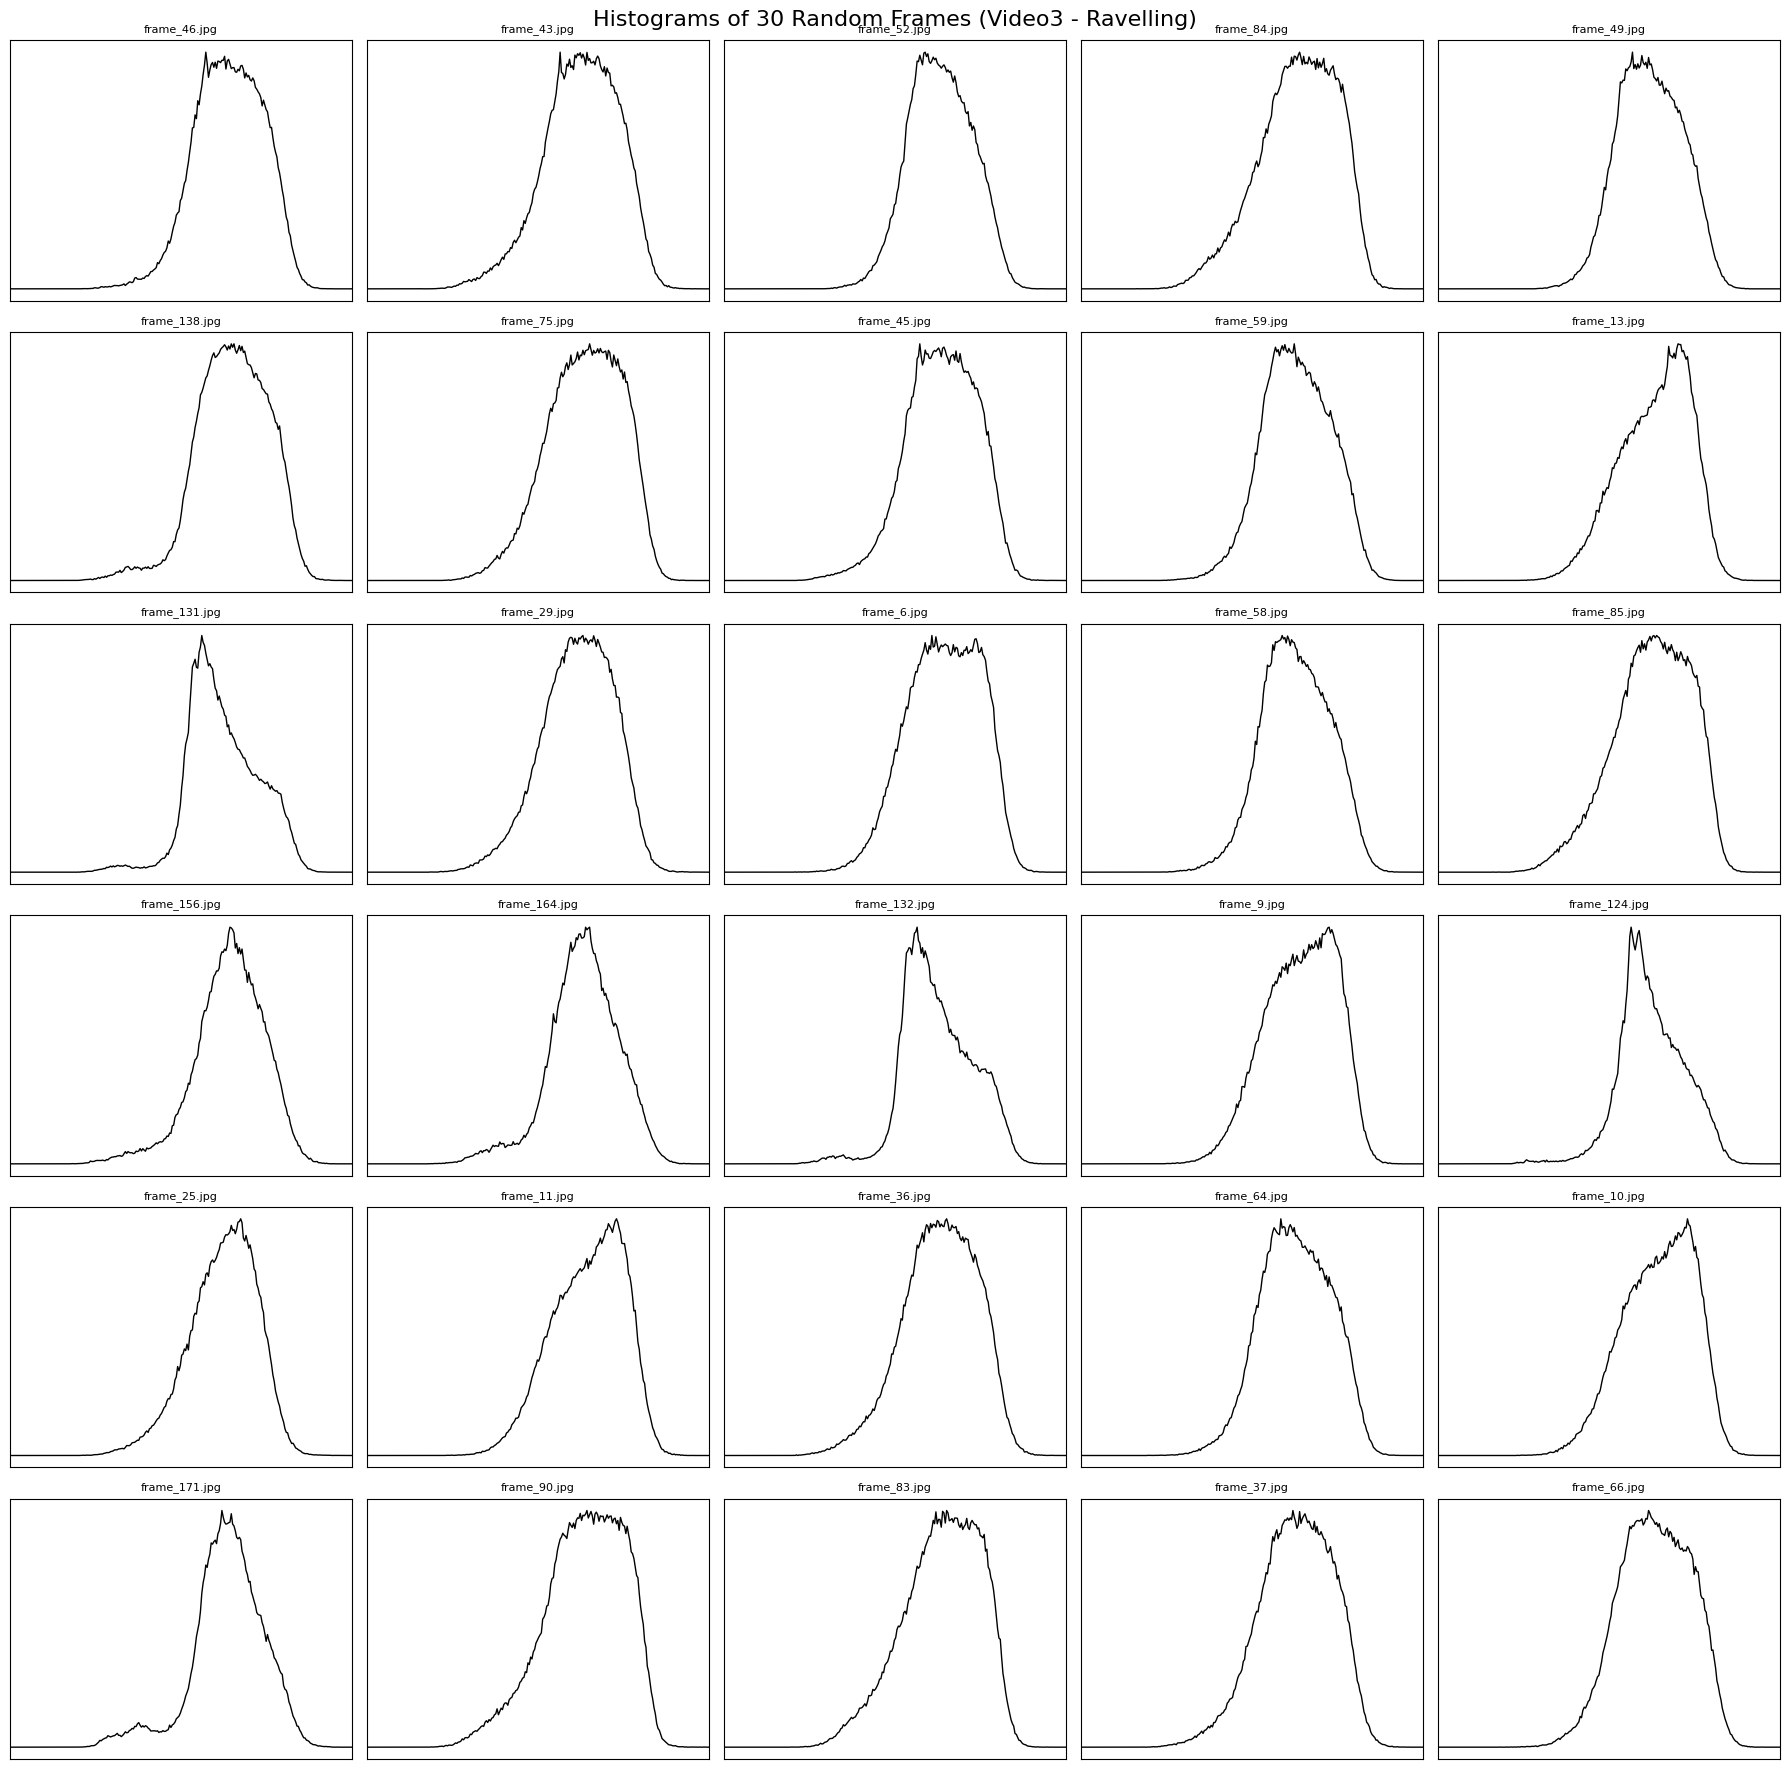

Analyzed frames: 30
Possible degradations summary:
  Noise-affected frames: 0
  Illumination-affected frames: 0
  Blur-affected frames: 0


,file,mean_brightness,sensor_noise_std,compression_blockiness,underexposed_pct,overexposed_pct,illumination_uneven_std,laplacian_var,noise_flag,illumination_flag,blur_flag
0,frame_46.jpg,163.30,9.39,0.49,0.0,0.48,13.35,867.28,False,False,False
1,frame_43.jpg,159.65,9.58,0.41,0.0,0.44,15.55,883.99,False,False,False
2,frame_52.jpg,161.41,9.38,0.58,0.0,0.30,10.74,868.19,False,False,False
3,frame_84.jpg,161.91,8.89,0.16,0.0,0.51,18.45,761.01,False,False,False
4,frame_49.jpg,158.27,9.24,0.36,0.0,0.17,12.03,854.35,False,False,False
5,frame_138.jpg,166.20,8.00,0.25,0.0,1.08,18.89,625.04,False,False,False
6,frame_75.jpg,162.40,8.89,0.48,0.0,0.53,16.72,767.85,False,False,False
7,frame_45.jpg,162.26,9.36,0.34,0.0,0.46,14.26,854.28,False,False,False
8,frame_59.jpg,160.77,9.62,0.32,0.0,0.49,12.90,908.29,False,False,False
9,frame_13.jpg,161.92,8.97,0.36,0.0,0.25,13.46,746.14,False,False,False


In [7]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

source_folder = "extracted_All_framesVideo3"
filtered_folder = "filteredVideo3"
os.makedirs(filtered_folder, exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
image_files = [f for f in os.listdir(source_folder) if f.lower().endswith(image_exts)]
image_files.sort()

if len(image_files) == 0:
    raise FileNotFoundError(f"No images found in '{source_folder}'")

sample_size = min(30, len(image_files))
selected_files = random.sample(image_files, sample_size)


def sensor_noise_std(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    residual = gray.astype(np.float32) - blur.astype(np.float32)
    return float(np.std(residual))


def compression_blockiness(gray):
    gray = gray.astype(np.float32)
    h, w = gray.shape

    vertical_boundaries = [x for x in range(8, w, 8)]
    horizontal_boundaries = [y for y in range(8, h, 8)]

    if len(vertical_boundaries) == 0 or len(horizontal_boundaries) == 0:
        return 0.0

    vb = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vertical_boundaries])
    hb = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in horizontal_boundaries])

    vsi = [x for x in range(9, w - 1, 8)]
    hsi = [y for y in range(9, h - 1, 8)]

    vi = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vsi]) if len(vsi) else 0.0
    hi = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in hsi]) if len(hsi) else 0.0

    return float(max(0.0, (vb + hb) - (vi + hi)))


def illumination_metrics(gray):
    under_pct = float(np.mean(gray < 40) * 100)
    over_pct = float(np.mean(gray > 215) * 100)

    illum_map = cv2.GaussianBlur(gray.astype(np.float32), (51, 51), 0)
    uneven_std = float(np.std(illum_map))

    return under_pct, over_pct, uneven_std


def blur_score(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


records = []

plt.figure(figsize=(18, 18))
for idx, fname in enumerate(selected_files, start=1):
    path = os.path.join(source_folder, fname)
    img = cv2.imread(path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    s_noise = sensor_noise_std(gray)
    c_noise = compression_blockiness(gray)
    under_pct, over_pct, uneven_std = illumination_metrics(gray)
    lap_var = blur_score(gray)
    mean_brightness = float(np.mean(gray))

    low_light_noise = (mean_brightness < 90) and (s_noise > 9.0)
    noise_flag = (s_noise > 10.0) or (c_noise > 2.5) or low_light_noise
    illumination_flag = (under_pct > 20.0) or (over_pct > 10.0) or (uneven_std > 30.0)
    blur_flag = lap_var < 80.0

    records.append(
        {
            "file": fname,
            "mean_brightness": round(mean_brightness, 2),
            "sensor_noise_std": round(s_noise, 2),
            "compression_blockiness": round(c_noise, 2),
            "underexposed_pct": round(under_pct, 2),
            "overexposed_pct": round(over_pct, 2),
            "illumination_uneven_std": round(uneven_std, 2),
            "laplacian_var": round(lap_var, 2),
            "noise_flag": bool(noise_flag),
            "illumination_flag": bool(illumination_flag),
            "blur_flag": bool(blur_flag),
        }
    )

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    plt.subplot(6, 5, idx)
    plt.plot(hist, color="black", linewidth=1)
    plt.title(fname, fontsize=8)
    plt.xlim(0, 255)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Histograms of 30 Random Frames (Video3 - Ravelling)", fontsize=16)
plt.tight_layout()
plt.show()

analysis_df = pd.DataFrame(records)

print(f"Analyzed frames: {len(analysis_df)}")
print("Possible degradations summary:")
print(f"  Noise-affected frames: {int(analysis_df['noise_flag'].sum())}")
print(f"  Illumination-affected frames: {int(analysis_df['illumination_flag'].sum())}")
print(f"  Blur-affected frames: {int(analysis_df['blur_flag'].sum())}")

analysis_df.head(10)

Filtered images saved: 30
Output folder: filteredVideo3


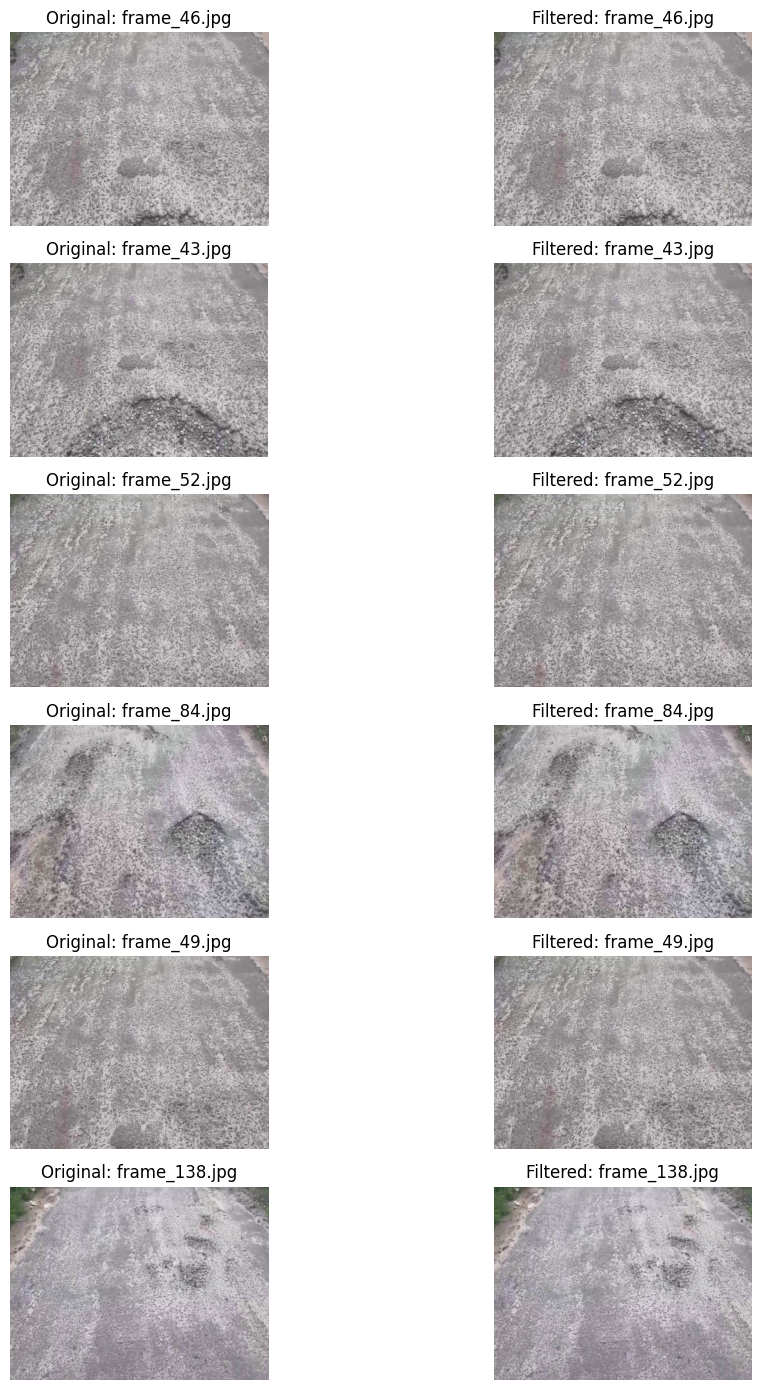

In [8]:
def apply_adaptive_filter(img_bgr, row):
    out = img_bgr.copy()

    if row["noise_flag"]:
        out = cv2.fastNlMeansDenoisingColored(out, None, 7, 7, 7, 21)

    if row["illumination_flag"]:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        out = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)

    if row["blur_flag"]:
        blur = cv2.GaussianBlur(out, (0, 0), 1.1)
        out = cv2.addWeighted(out, 1.55, blur, -0.55, 0)

    return out


saved = 0
preview_pairs = []

for _, row in analysis_df.iterrows():
    src_path = os.path.join(source_folder, row["file"])
    dst_path = os.path.join(filtered_folder, row["file"])

    img = cv2.imread(src_path)
    if img is None:
        continue

    filtered = apply_adaptive_filter(img, row)
    cv2.imwrite(dst_path, filtered)

    if len(preview_pairs) < 6:
        preview_pairs.append((img, filtered, row["file"]))

    saved += 1

print(f"Filtered images saved: {saved}")
print(f"Output folder: {filtered_folder}")

if len(preview_pairs) > 0:
    plt.figure(figsize=(12, 14))
    for i, (orig, filt, fname) in enumerate(preview_pairs, start=1):
        plt.subplot(len(preview_pairs), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview_pairs), 2, 2 * i)
        plt.imshow(cv2.cvtColor(filt, cv2.COLOR_BGR2RGB))
        plt.title(f"Filtered: {fname}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Ravelling detection and marking
This section detects road surface deterioration (ravelling, potholes, aggregate loss) in filtered images and draws boxes around the detected regions.

Processed images: 30
Marked-output folder: detectedRavellingVideo3
Images with at least one detected rough surface: 0


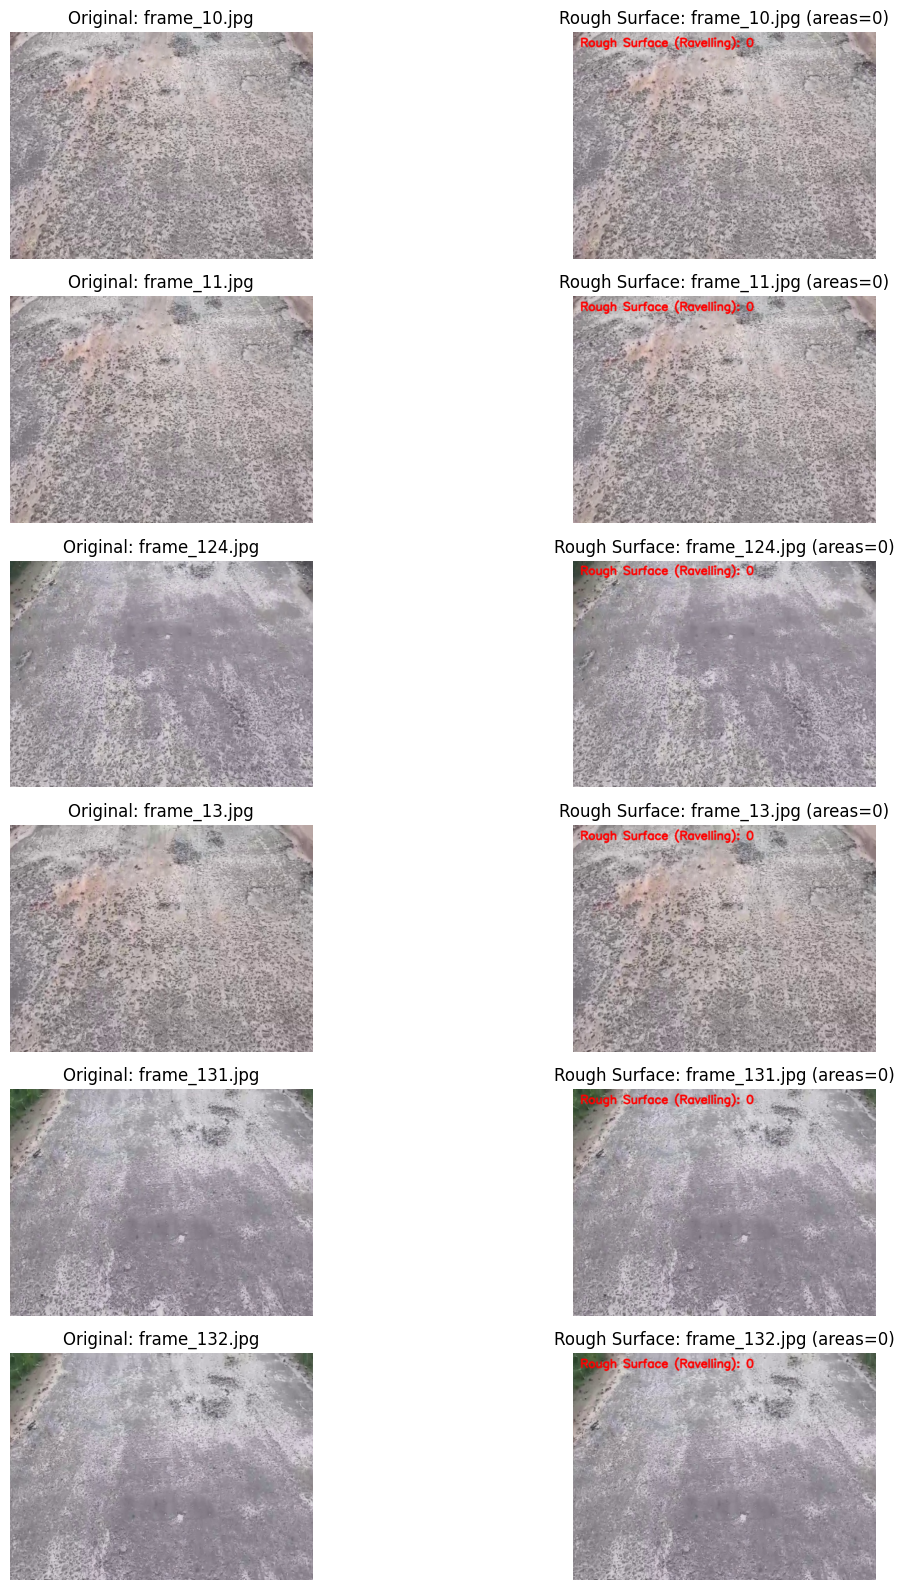

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

filtered_folder = "filteredVideo3"
input_folder = filtered_folder
marked_folder = "detectedRavellingVideo3"
os.makedirs(marked_folder, exist_ok=True)


def detect_ravelling_parts(img_bgr):
    """
    Detects road surface deterioration (ravelling, potholes, aggregate loss).
    Focuses on rough surface texture and LIGHT SPOTS (exposed aggregate).
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    # 1. Multi-scale contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(5, 5))
    gray_eq = clahe.apply(gray)
    
    # 2. Local texture roughness detection at multiple scales
    # Scale 1: Fine texture (small kernel for micro-roughness)
    fine_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    fine_mean = cv2.morphologyEx(gray_eq, cv2.MORPH_OPEN, fine_kernel, iterations=1)
    fine_variance = np.abs(gray_eq.astype(np.float32) - fine_mean.astype(np.float32))
    fine_variance = np.uint8(np.clip(fine_variance, 0, 255))
    
    # Scale 2: Medium texture (medium kernel)
    medium_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    medium_mean = cv2.morphologyEx(gray_eq, cv2.MORPH_OPEN, medium_kernel, iterations=1)
    medium_variance = np.abs(gray_eq.astype(np.float32) - medium_mean.astype(np.float32))
    medium_variance = np.uint8(np.clip(medium_variance, 0, 255))
    
    # Scale 3: Coarse texture (larger kernel)
    coarse_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    coarse_mean = cv2.morphologyEx(gray_eq, cv2.MORPH_OPEN, coarse_kernel, iterations=1)
    coarse_variance = np.abs(gray_eq.astype(np.float32) - coarse_mean.astype(np.float32))
    coarse_variance = np.uint8(np.clip(coarse_variance, 0, 255))
    
    # 3. Combine multi-scale texture maps (rough surfaces show high variance at all scales)
    combined_texture = np.maximum(np.maximum(fine_variance, medium_variance), coarse_variance)
    
    # 4. Texture threshold - detect rough areas
    _, rough_mask = cv2.threshold(combined_texture, 20, 255, cv2.THRESH_BINARY)
    
    # 5. Light spots detection (exposed aggregate, reflective roughness)
    # Top-hat highlights small bright regions
    tophat_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    tophat = cv2.morphologyEx(gray_eq, cv2.MORPH_TOPHAT, tophat_kernel)
    _, bright_mask = cv2.threshold(tophat, 15, 255, cv2.THRESH_BINARY)
    
    # 6. Bright intensity mask (global bright areas)
    _, bright_global = cv2.threshold(gray_eq, 185, 255, cv2.THRESH_BINARY)
    
    # 7. Edge-based detection using Sobel
    sobelx = cv2.Sobel(gray_eq, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray_eq, cv2.CV_64F, 0, 1, ksize=3)
    edge_magnitude = np.sqrt(sobelx**2 + sobely**2)
    edge_magnitude = np.uint8(np.clip(edge_magnitude, 0, 255))
    _, edge_mask = cv2.threshold(edge_magnitude, 25, 255, cv2.THRESH_BINARY)
    
    # 8. Gradient-based roughness (local intensity changes)
    gradient = cv2.Laplacian(gray_eq, cv2.CV_64F)
    gradient = np.uint8(np.clip(np.abs(gradient), 0, 255))
    _, gradient_mask = cv2.threshold(gradient, 15, 255, cv2.THRESH_BINARY)
    
    # 9. Dark spots detection (potholes, material loss)
    _, dark_mask = cv2.threshold(gray_eq, 100, 255, cv2.THRESH_BINARY_INV)
    
    # 10. Combine all masks - emphasize texture and bright spots
    combined = cv2.bitwise_or(rough_mask, edge_mask)
    combined = cv2.bitwise_or(combined, gradient_mask)
    combined = cv2.bitwise_or(combined, dark_mask)
    combined = cv2.bitwise_or(combined, bright_mask)
    combined = cv2.bitwise_or(combined, bright_global)
    
    # 11. Morphological operations to clean and connect regions
    clean_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, clean_kernel, iterations=1)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, clean_kernel, iterations=1)
    combined = cv2.dilate(combined, clean_kernel, iterations=2)
    
    # 12. Find contours
    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_area = h * w
    detections = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # Filter by area
        if area < 80 or area > 0.45 * img_area:
            continue
        
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bh == 0 or bw == 0:
            continue
        
        # Aspect ratio - allow compact and elongated shapes
        aspect_ratio = max(bw, bh) / float(min(bw, bh))
        if aspect_ratio < 1.0:
            continue
        
        # Solidity
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity = area / float(hull_area)
        
        # Very relaxed solidity for fragmented rough surfaces
        if solidity < 0.15:
            continue
        
        # Extract region and analyze texture intensity
        region = gray_eq[y:y+bh, x:x+bw]
        if region.size > 0:
            region_variance = np.var(region)
            region_bright = np.mean(region > 185)
        else:
            region_variance = 0
            region_bright = 0
        
        # Must have sufficient texture variance or bright spot density
        if region_variance < 50 and region_bright < 0.05:
            continue
        
        cx = x + bw // 2
        cy = y + bh // 2
        
        detections.append(
            {
                "bbox": (x, y, bw, bh),
                "center": (cx, cy),
                "area": area,
                "aspect_ratio": aspect_ratio,
                "solidity": solidity,
                "texture_variance": region_variance,
                "bright_ratio": region_bright,
            }
        )
    
    detections = sorted(detections, key=lambda d: d["center"][1])
    return detections, combined


files = [f for f in os.listdir(input_folder) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
files.sort()

summary = []
preview = []

for fname in files:
    src_path = os.path.join(input_folder, fname)
    dst_path = os.path.join(marked_folder, fname)

    img = cv2.imread(src_path)
    if img is None:
        continue

    detections, _ = detect_ravelling_parts(img)
    marked = img.copy()

    # Draw red borders around detected ravelling regions (potholes, deterioration)
    ravelling_color = (0, 0, 255)  # Red for ravelling/deterioration

    for d in detections:
        x, y, bw, bh = d["bbox"]
        cv2.rectangle(marked, (x, y), (x + bw, y + bh), ravelling_color, 2)

    label = f"Rough Surface (Ravelling): {len(detections)}"
    cv2.putText(marked, label, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, ravelling_color, 2, cv2.LINE_AA)

    cv2.imwrite(dst_path, marked)

    summary.append({"file": fname, "detected_ravelling": len(detections)})

    if len(preview) < 6:
        preview.append((img, marked, fname, len(detections)))

print(f"Processed images: {len(summary)}")
print(f"Marked-output folder: {marked_folder}")
print(f"Images with at least one detected rough surface: {sum(1 for s in summary if s['detected_ravelling'] > 0)}")

if len(preview) > 0:
    plt.figure(figsize=(14, 16))
    for i, (orig, marked, fname, n) in enumerate(preview, start=1):
        plt.subplot(len(preview), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview), 2, 2 * i)
        plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        plt.title(f"Rough Surface: {fname} (areas={n})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()